# Nonesuch Formation ca. 1077 Ma paleomagnetic pole

## Geologic context

The Nonesuch Formation is a fine-grained, organic-rich, fluviolacustrine unit of the Oronto Group, deposited in the North American Midcontinent Rift basin at *ca.* 1080 to 1075 Ma — after the cessation of voluminous rift volcanism, as the basin continued to subside by post-rift thermal subsidence (Slotznick et al., 2024; Fuentes et al., 2025). It conformably overlies the alluvial-fan and fluvial-plain Copper Harbor Conglomerate and is conformably overlain by the >3 km-thick fluvial Freda Formation; the three units make up the Oronto Group. The Nonesuch records a tropical (paleolatitude 7.1 ± 2.8°N), oxygenated lacustrine water body whose remarkably preserved microbiota include both cyanobacteria and eukaryotes — its low metamorphic grade (Gallagher et al., 2017) yields excellent preservation of both fossils and primary magnetic minerals.

Slotznick et al. (2024) developed paleomagnetic data from the Potato River Falls (PRF18) section in northern Wisconsin — ~160 m of red-bed and gray lacustrine strata sampled at <0.5 m spacing with each sample being a site and considered as independent snapshots of the geomagnetic field.

## Paleomagnetic and rock magnetic data

Stepwise thermal demagnetization (steps narrowed to 5–1 °C approaching the ~690 °C Néel temperature of hematite) with principal-component analysis isolates several remanence components. Coercivity-spectrum unmixing, hysteresis, low-temperature (MPMS) measurements, and SEM-EDS petrography resolve four ferromagnetic populations: low-coercivity (titano)magnetite/maghemite, detrital near-stoichiometric magnetite (mt), pigmentary hematite (hct), and high-coercivity detrital hematite (hdt).

The detrital hematite (hdt, n = 105) and detrital magnetite (mt, n = 77) components carry a westerly, shallow, single-polarity detrital remanent magnetization (DRM) that shares a common mean and is interpreted as a primary, near-depositional remanence. The lower-unblocking pigmentary hematite (hct) carries a distinct, slightly older-looking chemical remanent magnetization (CRM) that defines a separate (nearby) Mesoproterozoic pole and does not enter the DRM pole. The DRM, corrected for inclination shallowing by the elongation/inclination (E/I) method (Tauxe & Kent, 2004) with uncertainty propagated following Pierce et al. (2022), gives the reported pole at 6.6°N, 182.9°E (A95 ≈ 2.4°) — this notebook reproduces that result from the published MagIC contribution [20614](https://earthref.org/MagIC/20614).

## Age constraints

- Best estimate *ca.* 1077 Ma. The Bayesian thermal-subsidence age model of Fuentes et al. (2025) gives 1077.3 Ma for Nonesuch deposition with 95% credible bounds of 1085.5 / 1066.3 Ma, integrating the U-Pb CA-ID-TIMS andesite date of 1085.57 ± 0.25 Ma from the Lake Shore Traps in the underlying Copper Harbor Conglomerate (Fairchild et al., 2017), the Re-Os date of 1078 ± 24 Ma on Nonesuch organic-rich facies (Cumming et al., 2013), and the U-Pb CA-ID-TIMS detrital-zircon maximum depositional age of 1051.6 ± 1.1 Ma from the upper Freda Formation (Hodgin et al., 2024).

## References

- Slotznick, S. P., Swanson-Hysell, N. L., Zhang, Y., Clayton, K. E., Wellman, C. H., Tosca, N. J., & Strother, P. K. (2024). Reconstructing the paleoenvironment of an oxygenated Mesoproterozoic shoreline and its record of life. *GSA Bulletin*, 136(7–8), 2842–2864. https://doi.org/10.1130/B37100.1
- Fuentes, A. J., Fairchild, L. M., Hodgin, E. B., Alemu, T., & Swanson-Hysell, N. L. (2025). Termination of Laurentia's rapid plate motion at the start of the Grenvillian Orogeny. *Journal of Geophysical Research: Solid Earth*, 130, e2025JB031794. https://doi.org/10.1029/2025JB031794
- Henry, S. G., Mauk, F. J., & Van der Voo, R. (1977). Paleomagnetism of the upper Keweenawan sediments: the Nonesuch Shale and Freda Sandstone. *Canadian Journal of Earth Sciences*, 14, 1128–1138.
- Tauxe, L., & Kent, D. V. (2004). A simplified statistical model for the geomagnetic field… In *Timescales of the Paleomagnetic Field* (AGU Geophysical Monograph 145), 101–115.
- Pierce, J. W., et al. (2022); Fairchild et al. (2017); Cumming et al. (2013); Hodgin et al. (2024) — see in-text citations.

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

The data are pulled from the published MagIC contribution [20614](https://earthref.org/MagIC/20614) (Slotznick et al., 2024) with `pt.fetch_magic_contribution`, which caches the contribution locally so the notebook runs offline. The `sites` table holds the specimen-level component directions; each "site" is a single specimen from the Potato River Falls section (one per sample, at <0.5 m spacing). We work with the tilt-corrected (`dir_tilt_correction = 100`) directions of the detrital hematite (`hdt`), detrital magnetite (`mt`), and pigmentary hematite (`hct`) components.

In [2]:
pt.fetch_magic_contribution('20614', '../data/1078_Nonesuch')
sites = pd.read_csv('../data/1078_Nonesuch/sites.txt', sep='\t', skiprows=1)
locations = pd.read_csv('../data/1078_Nonesuch/locations.txt', sep='\t', skiprows=1)

def component(name, tilt=100):
    return sites[(sites['dir_comp_name'] == name) & (sites['dir_tilt_correction'] == tilt)].reset_index(drop=True)

hdt = component('hdt')   # detrital hematite (DRM)
mt = component('mt')     # detrital magnetite (DRM)
hct = component('hct')   # pigmentary hematite (CRM)
print(f'detrital hematite (hdt): n = {len(hdt)}')
print(f'detrital magnetite (mt): n = {len(mt)}')
print(f'pigmentary hematite (hct): n = {len(hct)}')
locations[['location', 'result_name', 'dir_tilt_correction', 'dir_dec', 'dir_inc',
           'pole_lat', 'pole_lon', 'pole_alpha95']]

Download successful. File saved to: ../data/1078_Nonesuch/magic_contribution_20614.txt
1  records written to file  /Users/hematite/Documents/GitHub/2026_Laurentia_Precambrian_poles/data/1078_Nonesuch/contribution.txt
9  records written to file  /Users/hematite/Documents/GitHub/2026_Laurentia_Precambrian_poles/data/1078_Nonesuch/locations.txt
655  records written to file  /Users/hematite/Documents/GitHub/2026_Laurentia_Precambrian_poles/data/1078_Nonesuch/sites.txt
163  records written to file  /Users/hematite/Documents/GitHub/2026_Laurentia_Precambrian_poles/data/1078_Nonesuch/samples.txt
980  records written to file  /Users/hematite/Documents/GitHub/2026_Laurentia_Precambrian_poles/data/1078_Nonesuch/specimens.txt
6698  records written to file  /Users/hematite/Documents/GitHub/2026_Laurentia_Precambrian_poles/data/1078_Nonesuch/measurements.txt
-I- Using MagIC contribution 20614 downloaded from earthref.org
detrital hematite (hdt): n = 105
detrital magnetite (mt): n = 77
pigmentary he

,location,result_name,dir_tilt_correction,dir_dec,dir_inc,pole_lat,pole_lon,pole_alpha95
0,Potato River Falls,Nonesuch hematite CRM,0,70.0,-50.1,NaN,NaN,NaN
1,Potato River Falls,Nonesuch hematite DRM,0,38.5,-49.6,NaN,NaN,NaN
2,Potato River Falls,Present day field overprint,0,356.0,74.2,NaN,NaN,NaN
3,Potato River Falls,Nonesuch maghemite? CRM,0,84.6,-54.3,NaN,NaN,NaN
4,Potato River Falls,Nonesuch magnetite DRM,0,43.1,-54.2,NaN,NaN,NaN
5,Potato River Falls,Nonesuch hematite CRM,100,276.0,-11.5,NaN,NaN,NaN
6,Potato River Falls,Nonesuch hematite DRM,100,270.1,7.8,6.6,182.9,2.4
7,Potato River Falls,Nonesuch maghemite? CRM,100,284.6,-16.7,NaN,NaN,NaN
8,Potato River Falls,Nonesuch magnetite DRM,100,274.8,5.3,NaN,NaN,NaN


## Component directions

The detrital hematite (hdt) and detrital magnetite (mt) directions form a single westerly, shallow group (the DRM); the pigmentary hematite (hct) CRM is offset to a distinct direction.

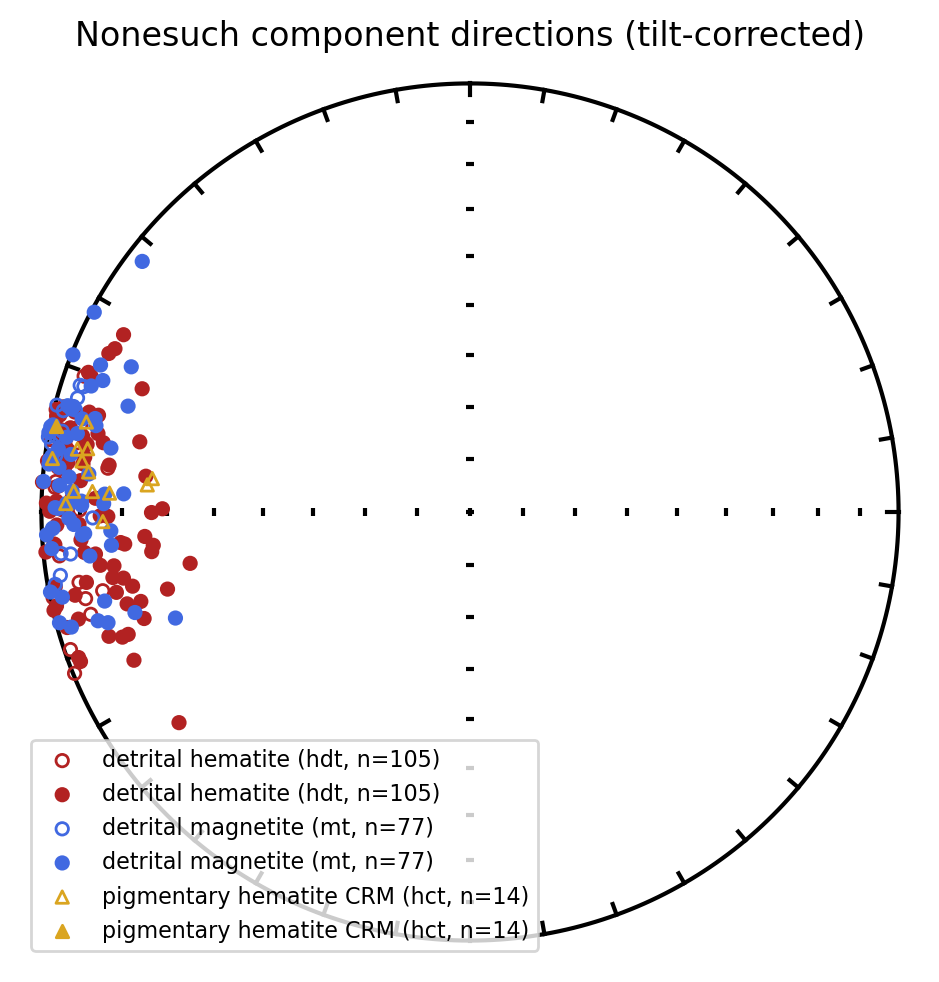

In [3]:
locality_lat, locality_lon = 46.5, -90.5   # Potato River Falls section

ipmag.plot_net()
ipmag.plot_di(dec=hdt['dir_dec'].tolist(), inc=hdt['dir_inc'].tolist(),
              color='firebrick', marker='o', label=f'detrital hematite (hdt, n={len(hdt)})')
ipmag.plot_di(dec=mt['dir_dec'].tolist(), inc=mt['dir_inc'].tolist(),
              color='royalblue', marker='o', label=f'detrital magnetite (mt, n={len(mt)})')
ipmag.plot_di(dec=hct['dir_dec'].tolist(), inc=hct['dir_inc'].tolist(),
              color='goldenrod', marker='^', label=f'pigmentary hematite CRM (hct, n={len(hct)})')
ipmag.plt.legend(loc=3, fontsize=8)
ipmag.plt.title('Nonesuch component directions (tilt-corrected)')
ipmag.plt.show()

## Common-mean test: detrital hematite vs. detrital magnetite

A bootstrap common-mean test (Tauxe et al., 2016) on the detrital hematite and detrital magnetite directions: the two carriers share a common mean, justifying their combination into a single DRM data set for the pole.

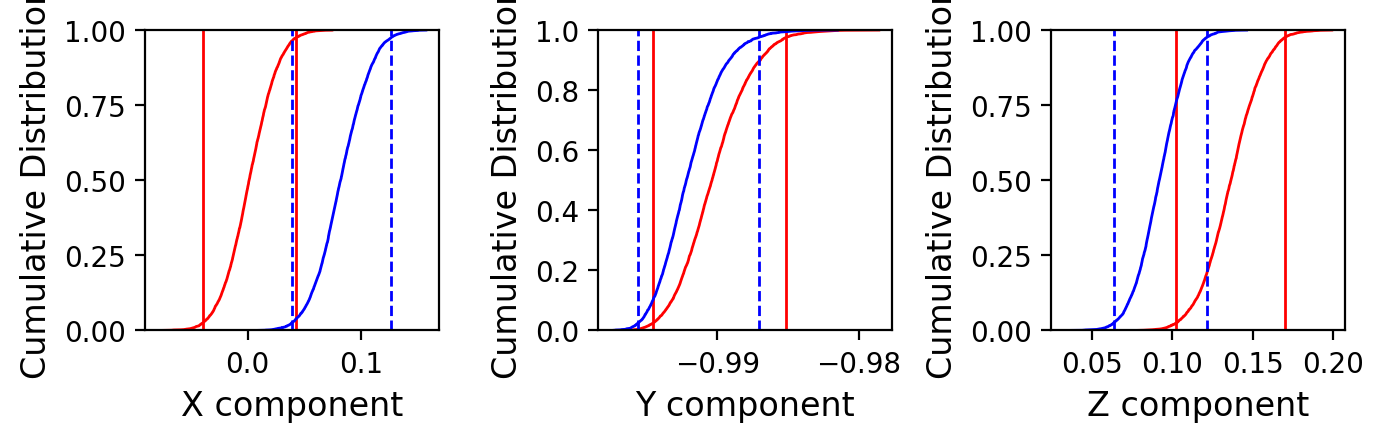

Pass


In [4]:
hdt_di = ipmag.make_di_block(hdt['dir_dec'].tolist(), hdt['dir_inc'].tolist())
mt_di = ipmag.make_di_block(mt['dir_dec'].tolist(), mt['dir_inc'].tolist())
ipmag.common_mean_bootstrap(hdt_di, mt_di)
plt.show()

## As-measured DRM mean direction and pole

The combined detrital hematite + magnetite (DRM) Fisher mean direction and the corresponding (as-measured, *uncorrected*) pole. Because these are flat-lying lacustrine sediments, the directions are shallow and the as-measured pole is biased to too-low paleolatitude by inclination shallowing — corrected next.

In [5]:
drm = pd.concat([hdt, mt]).reset_index(drop=True)
dir_mean = ipmag.fisher_mean(dec=drm['dir_dec'].tolist(), inc=drm['dir_inc'].tolist())
print('Combined DRM mean direction (as measured):')
ipmag.print_direction_mean(dir_mean)

flat_lon, flat_lat, _, _ = pmag.dia_vgp(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                                        locality_lat, locality_lon)
drm_vgps = [pmag.dia_vgp(d, i, 0, locality_lat, locality_lon)[:2]
            for d, i in zip(drm['dir_dec'], drm['dir_inc'])]
flat_pole = ipmag.fisher_mean([v[0] for v in drm_vgps], [v[1] for v in drm_vgps])
print('\nAs-measured DRM pole (no inclination correction):')
ipmag.print_pole_mean(flat_pole)

Combined DRM mean direction (as measured):
Dec: 272.1  Inc: 6.7
Number of directions in mean (n): 182
Angular radius of 95% confidence (a_95): 2.0
Precision parameter (k) estimate: 28.9

As-measured DRM pole (no inclination correction):
Plon: 180.4  Plat: 3.9
Number of directions in mean (n): 182
Angular radius of 95% confidence (A_95): 1.7
Precision parameter (k) estimate: 38.4


## Inclination-shallowing correction (E/I) and the DRM pole

Detrital remanence in flat-lying sediments is shallowed during compaction. Following Slotznick et al. (2024), the elongation/inclination (E/I) method of Tauxe & Kent (2004) recovers the flattening factor *f* and the corrected inclination by finding the *f* that makes the directional distribution's elongation match the TK03.GAD field-model expectation. We run the published method directly — `ipmag.find_ei_kent`, which propagates the correction through a Kent-ellipse uncertainty following Pierce et al. (2022) — so the cell below reproduces the Slotznick et al. (2024) DRM pole (6.6°N, 182.9°E) from the data rather than reading it back.

Bootstrapping.... be patient



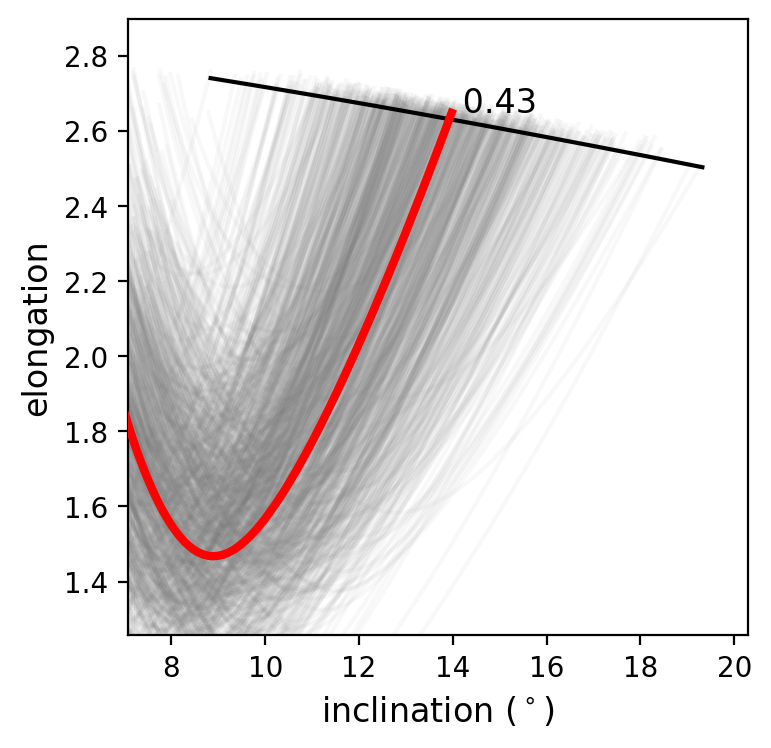

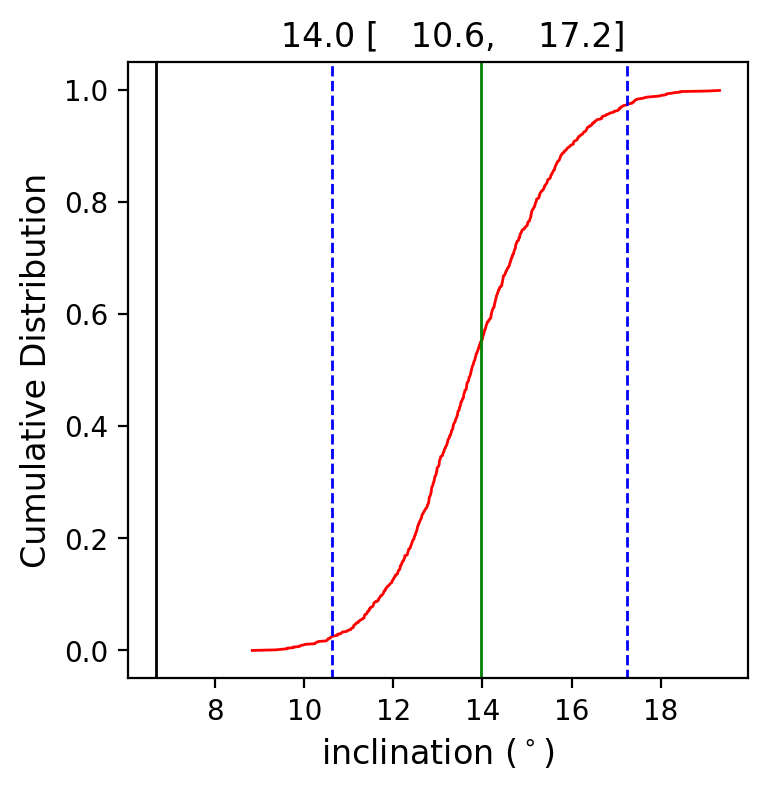

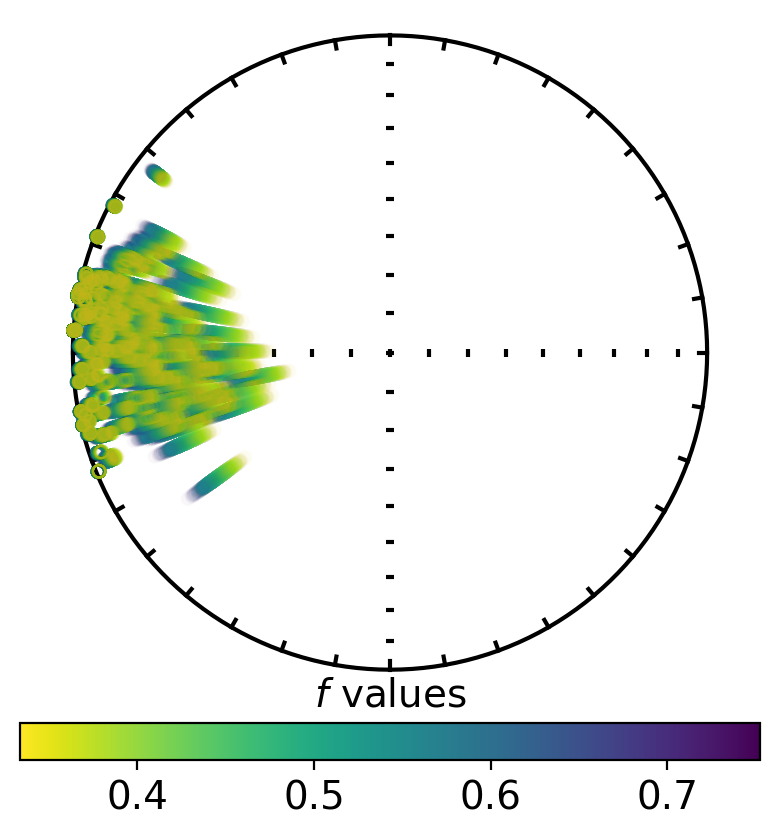

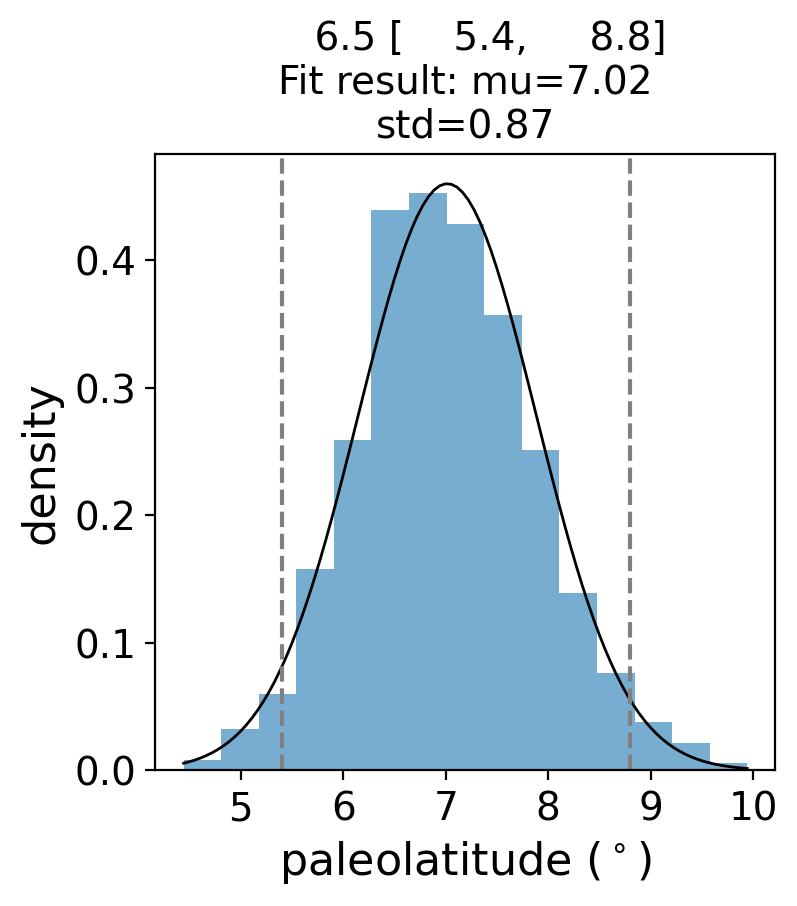

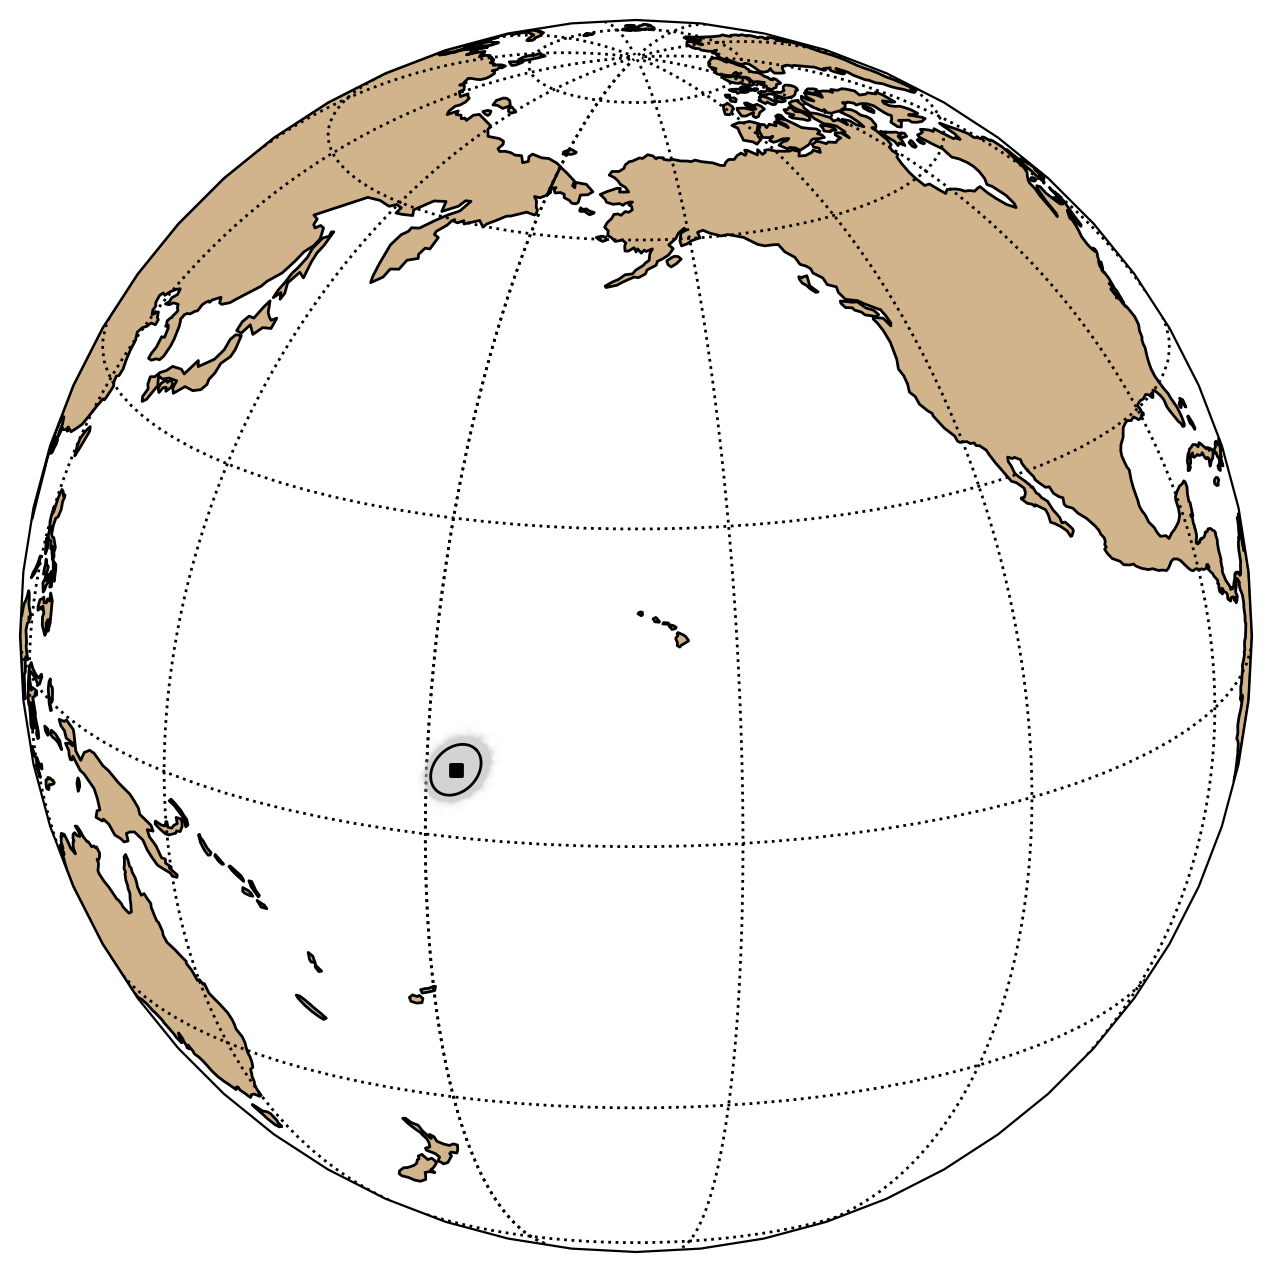

The original inclination was: 6.67

The corrected inclination is: 13.97
with bootstrapped confidence bounds of: 10.63 to 17.25
and elongation parameter of: 2.65
The flattening factor is: 0.43
with bootstrapped confidence bounds of: 0.62 to 0.38

The Kent mean incorporating inclination flattening uncertainty is:
Plon: 182.9  Plat: 6.6
Major axis lon: 280.1  Major axis lat: 47.5
Minor axis lon: 87.0  Minor axis lat: 41.8
Major axis angle of 95% ellipse (Zeta): 2.8
Minor axis angle of 95% ellipse (Eta): 2.0
Number of directions in mean (n): 100000
Inclination-corrected DRM pole (E/I + Kent, reproduced here): 6.6 N / 182.9 E  (Kent ellipse zeta95=2.8/eta95=2.0; A95~2.4)
Published DRM pole (MagIC 20614):                              6.6 N / 182.9 E, A95 2.4


In [6]:
# E/I correction with full Kent-ellipse uncertainty -- the published method
# (ipmag.find_ei_kent; ~2 min: nb=1000 directional + vgp_nb=100 VGP bootstraps).
# This reproduces the Slotznick et al. (2024) DRM pole directly from the data.
result_dir, kent_stats, I_boot, E_boot, F_boot = ipmag.find_ei_kent(
    hdt_di + mt_di, site_latitude=locality_lat, site_longitude=locality_lon,
    nb=1000, vgp_nb=100, return_new_dirs=1, return_values=1, save=0,
    central_longitude=200, central_latitude=20)
plt.show()

corr_pole = {'dec': kent_stats['dec'], 'inc': kent_stats['inc'],
             'alpha95': (kent_stats['Zeta'] * kent_stats['Eta']) ** 0.5}
zeta95, eta95 = kent_stats['Zeta'], kent_stats['Eta']
print(f"Inclination-corrected DRM pole (E/I + Kent, reproduced here): "
      f"{corr_pole['inc']:.1f} N / {corr_pole['dec']:.1f} E  "
      f"(Kent ellipse zeta95={zeta95:.1f}/eta95={eta95:.1f}; A95~{corr_pole['alpha95']:.1f})")

drm_pole_pub = locations[(locations['result_name'] == 'Nonesuch hematite DRM') &
                         (locations['dir_tilt_correction'] == 100)].iloc[0]
print(f"Published DRM pole (MagIC 20614):                              "
      f"{drm_pole_pub['pole_lat']:.1f} N / {drm_pole_pub['pole_lon']:.1f} E, A95 {drm_pole_pub['pole_alpha95']:.1f}")

## The DRM and CRM poles

The primary detrital (DRM) pole and the distinct pigmentary-hematite (CRM) pole, plotted together. The CRM pole is a separate, nearby Mesoproterozoic position that does not compromise the DRM age assignment.

Pigmentary-hematite CRM pole:
Plon: 171.1  Plat: -0.2
Number of directions in mean (n): 14
Angular radius of 95% confidence (A_95): 2.8
Precision parameter (k) estimate: 197.7


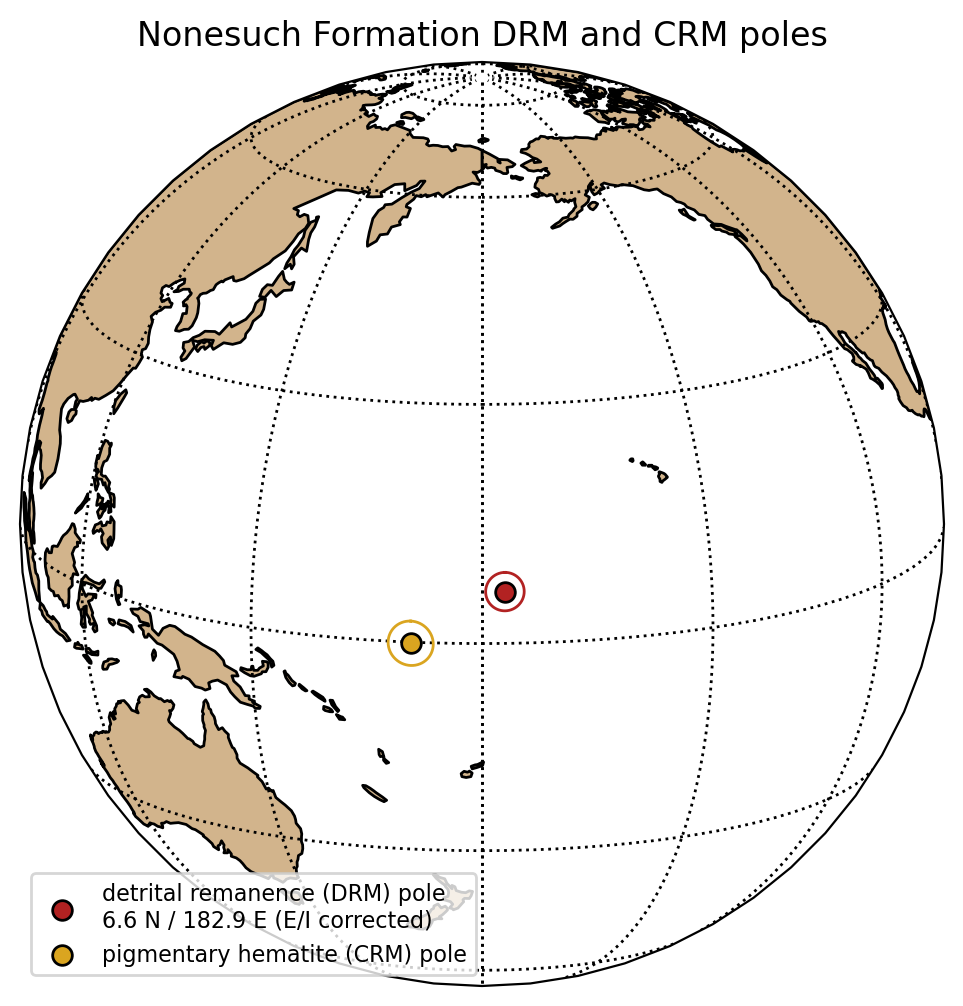

In [7]:
crm_vgps = [pmag.dia_vgp(d, i, 0, locality_lat, locality_lon)[:2]
            for d, i in zip(hct['dir_dec'], hct['dir_inc'])]
crm_pole = ipmag.fisher_mean([v[0] for v in crm_vgps], [v[1] for v in crm_vgps])
print('Pigmentary-hematite CRM pole:')
ipmag.print_pole_mean(crm_pole)

ax = ipmag.make_orthographic_map(central_longitude=180, central_latitude=15, figsize=(6, 6))
ipmag.plot_pole(ax, corr_pole['dec'], corr_pole['inc'], corr_pole['alpha95'],
                color='firebrick', markersize=50,
                label='detrital remanence (DRM) pole\n6.6 N / 182.9 E (E/I corrected)')
ipmag.plot_pole(ax, crm_pole['dec'], crm_pole['inc'], crm_pole['alpha95'],
                color='goldenrod', markersize=50, label='pigmentary hematite (CRM) pole')
plt.legend(loc=3, fontsize=8)
plt.title('Nonesuch Formation DRM and CRM poles')
plt.show()

## Paleosecular variation and VGP-shape diagnostics

The Fisher-quantile (fishqq) test assesses whether the DRM site VGPs are drawn from a
Fisher distribution, and the shape-elongation/inclination (SVEI) test compares the
VGP-scatter elongation against the TK03.GAD paleosecular-variation model expectation.

{'Mode': 'Mode 1',
 'Dec': np.float64(180.36298936427454),
 'Inc': np.float64(3.9273181662944854),
 'N': 182,
 'Mu': np.float64(3.2748296285719345),
 'Mu_critical': 1.207,
 'Me': np.float64(0.7529794168666314),
 'Me_critical': 1.094,
 'Test_result': 'Fisher distribution rejected'}

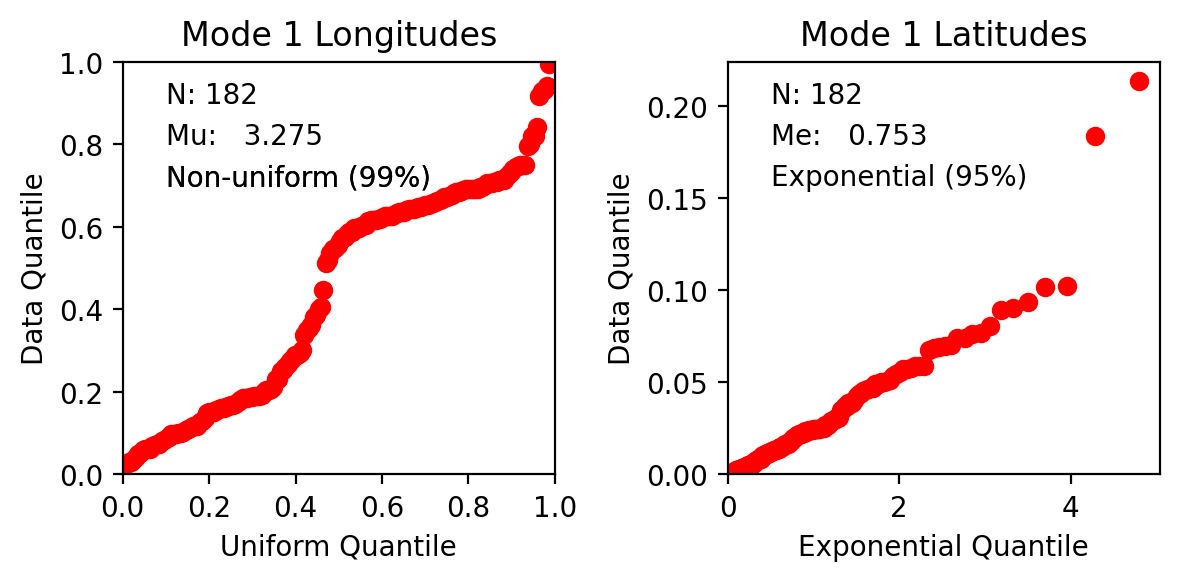

In [8]:
# build a VGP dataframe from the inline DRM VGPs for the diagnostics
nonesuch_vgp = drm.assign(vgp_lon=[v[0] for v in drm_vgps], vgp_lat=[v[1] for v in drm_vgps],
                          lat=locality_lat, lon=locality_lon)
fishqq_result = pt.fishqq_vgps(nonesuch_vgp, unify_polarity=False)
fishqq_result

(SVEI elongation plot skipped: E below the TK03.GAD model minimum)
paleolatitude = 3.3 deg; elongation E = 2.00 (inconsistent with TK03.GAD)


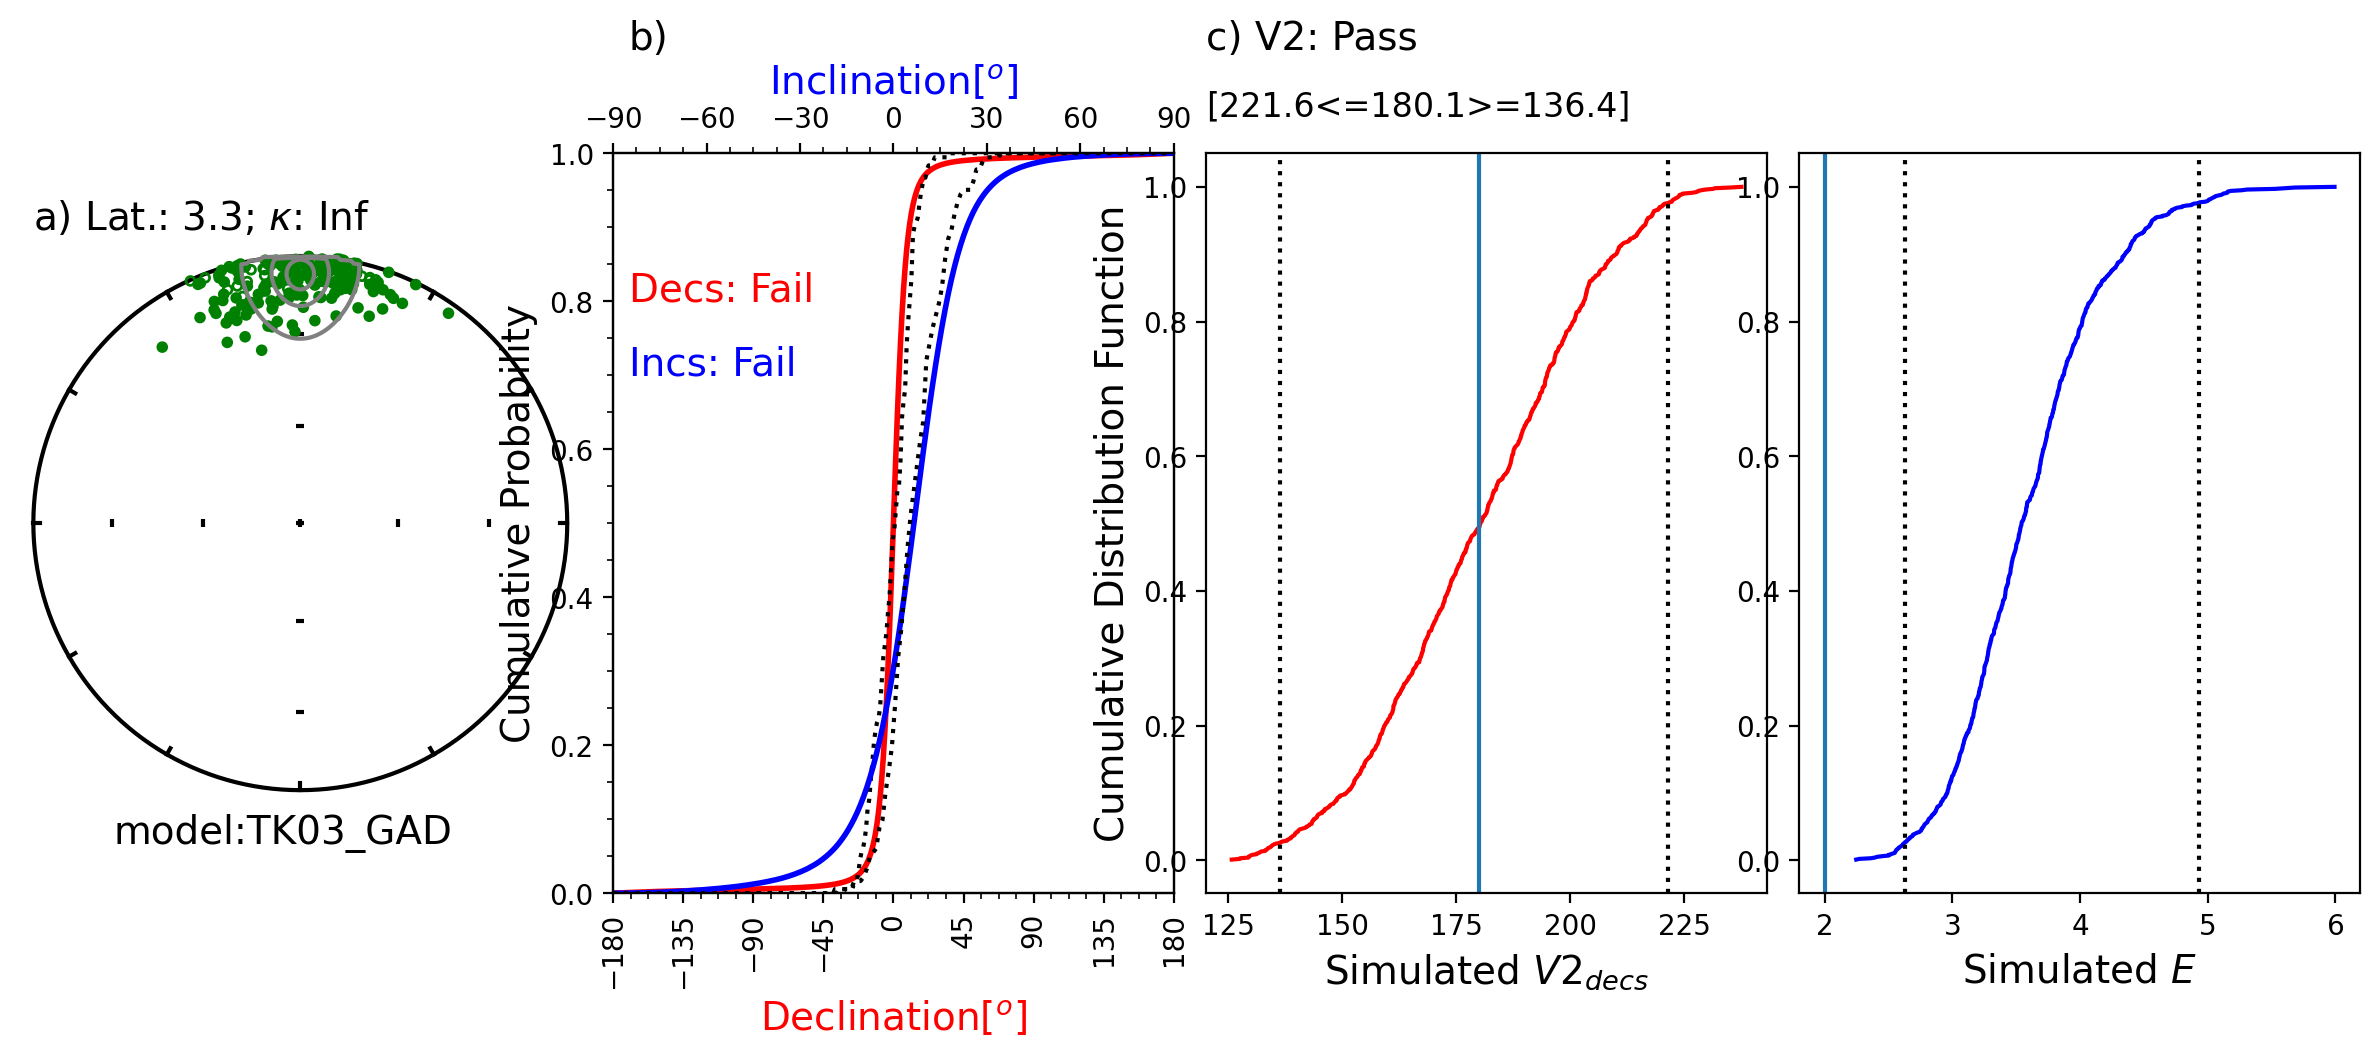

In [9]:
try:
    svei_result = pt.svei_test_vgps(nonesuch_vgp, locality_lon, locality_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(nonesuch_vgp, locality_lon, locality_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## Pole in the context of the Laurentia APWP

The Nonesuch DRM pole sits at the young end of the late Keweenawan Track, between the *ca.* 1084 Ma Michipicoten Island Formation pole and the *ca.* 1045–1075 Ma Freda Formation poles.

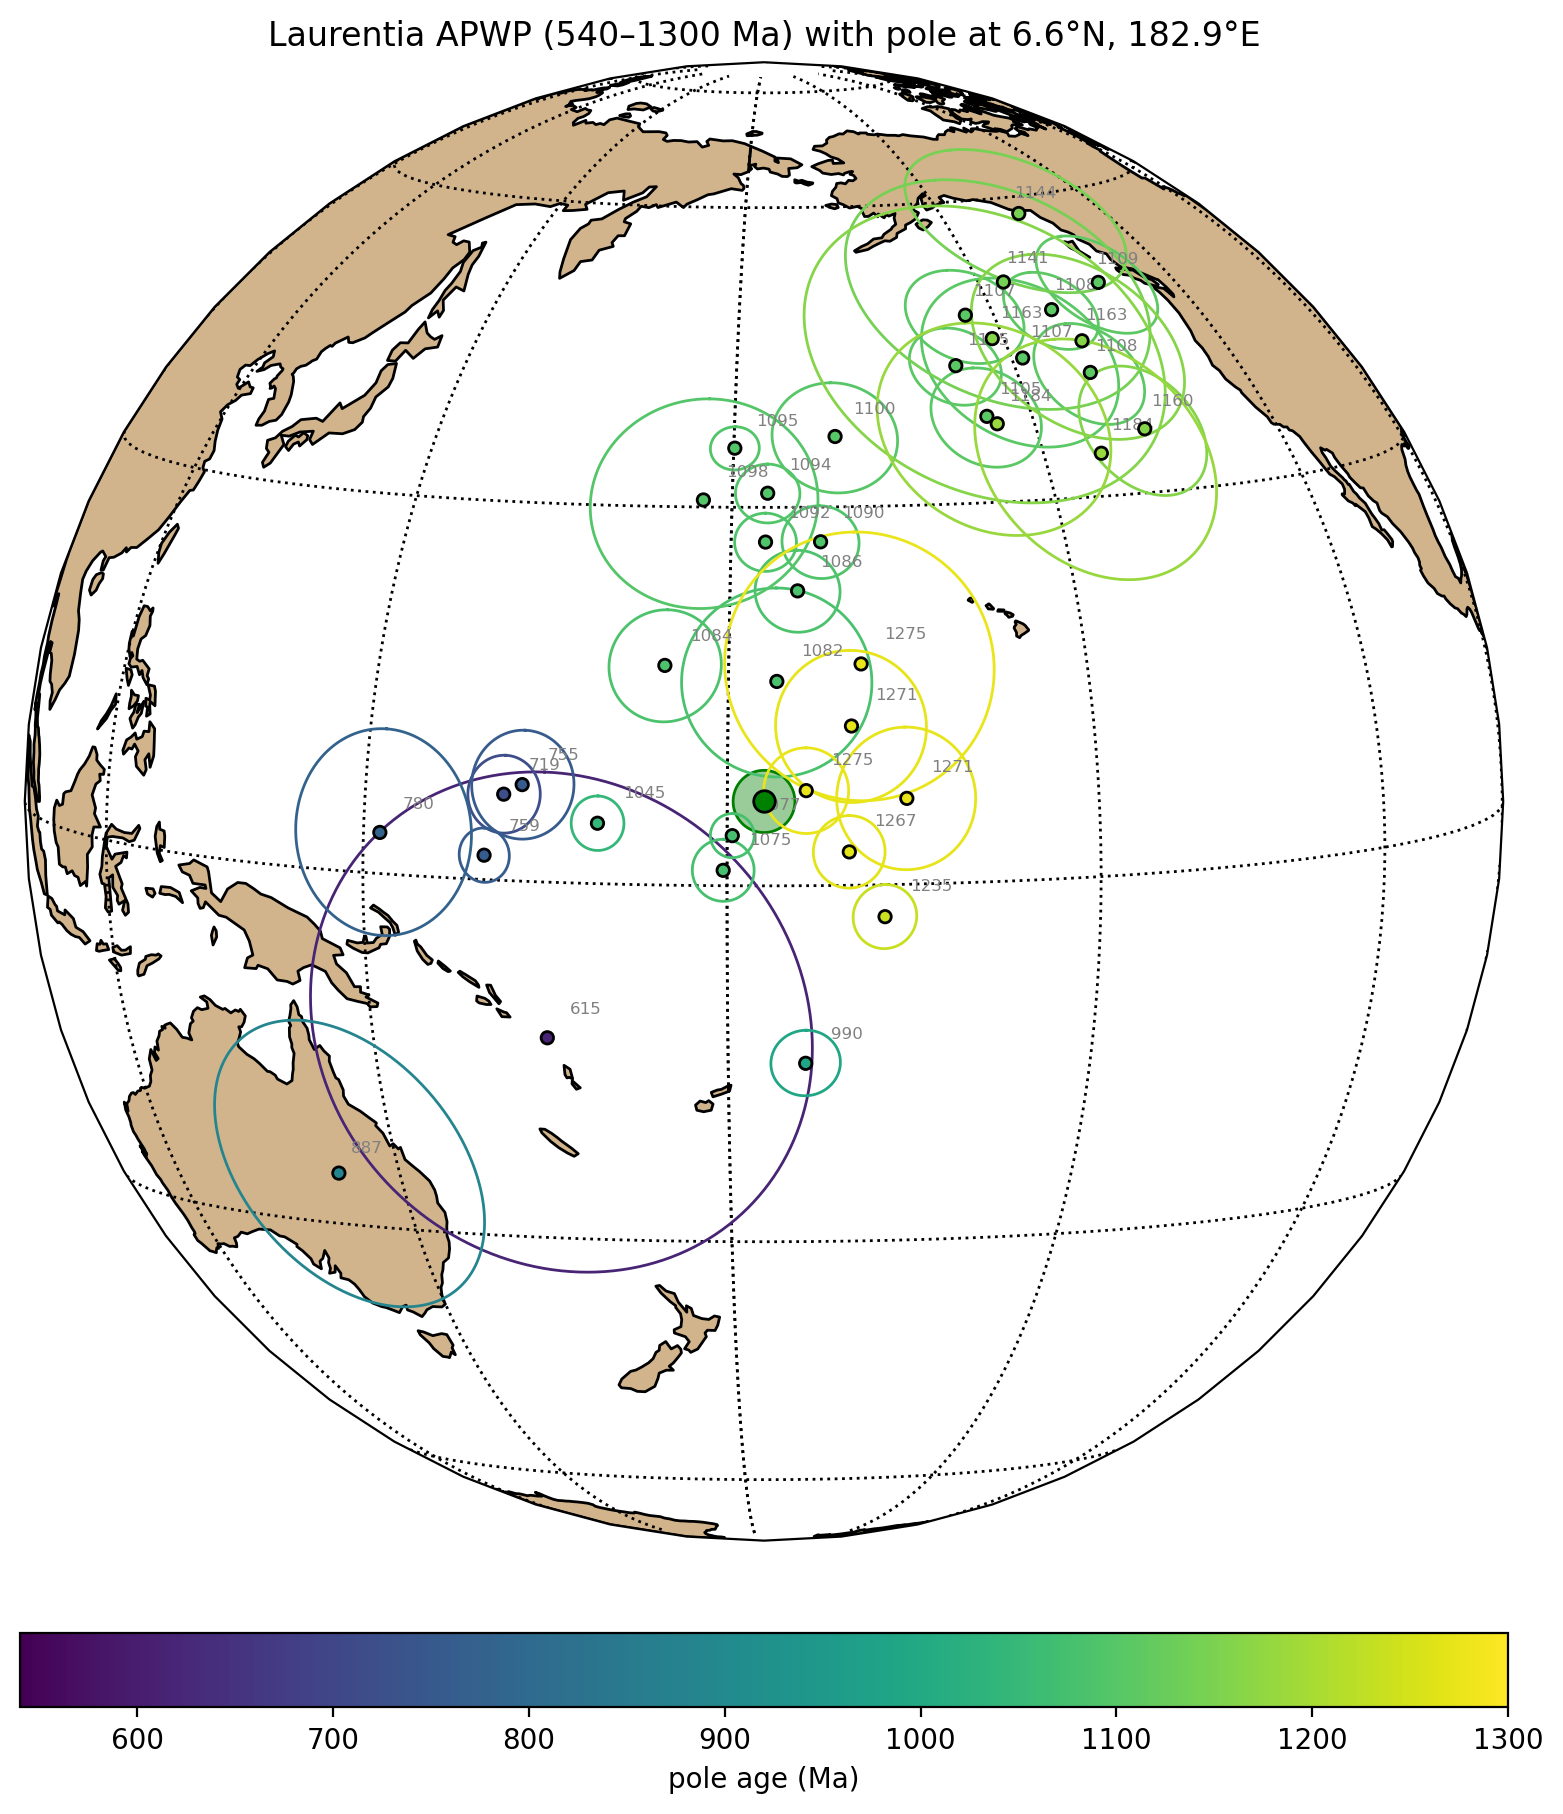

In [10]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, corr_pole['inc'], corr_pole['dec'],
                          corr_pole['alpha95'], age_min=540, age_max=1300,
                          projection='orthographic',
                          central_longitude=corr_pole['dec'],
                          central_latitude=corr_pole['inc'])
plt.show()

### R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | 1 | Best estimate ca. 1077 Ma. The Bayesian thermal subsidence age model of Fuentes et al. (2025) gives an age of 1,077.3 Ma with 95% credible bounds of 1,085.5 / 1,066.3 Ma for Nonesuch deposition, integrating the U-Pb CA-ID-TIMS andesite date of 1,085.57 ± 0.25 Ma from the Lake Shore Traps in the underlying Copper Harbor Conglomerate (Fairchild et al., 2017), the Re-Os date of 1,078 ± 24 Ma on Nonesuch organic-rich facies (Cumming et al., 2013), and the U-Pb CA-ID-TIMS detrital zircon maximum depositional age of 1,051.6 ± 1.1 Ma from the upper Freda Formation (Hodgin et al., 2024). The full credible interval falls within ± 15 Ma of the central age. |
| 2 | Techniques and statistical analysis | 1 | (a) High-resolution stepwise thermal demagnetization with 5–1°C steps approaching the Néel temperature of hematite (~690°C), enabling clean separation of the higher-unblocking detrital hematite component from the lower-unblocking pigmentary hematite component (lack of AF is appropriate for hematite-bearing lithologies). (b) PCA component fits using PmagPy (Kirschvink, 1980). (c) Pole based on n = 105 detrital hematite + n = 77 detrital magnetite specimen-sites from the Potato River Falls section (PRF18; ~160 m of section, samples spaced <0.5 m to capture distinct snapshots of the field). The overall pole A95 of ~2.4º passes Deenen et al. (2011) criteria. |
| 3 | Magnetic mineralogy characterized | 1 | Thorough rock magnetic and mineralogical characterization. Coercivity spectra (backfield demagnetization with MAX UnMix deconvolution) resolve four ferromagnetic populations: low-coercivity (titano)magnetite/maghemite, mid-coercivity detrital near-stoichiometric magnetite, mid-to-high-coercivity pigmentary hematite, and high-coercivity detrital hematite. Supporting data include hysteresis loops, low-temperature MPMS magnetic measurements, high-resolution thermal demagnetization curves, and SEM-EDS petrography. |
| 4 | Field tests constrain age of magnetization | 1 | Field test applied via the conformably overlying Freda Formation, whose lower fluvial red-bed lithofacies are the same as the red-bed lithofacies sampled within the Nonesuch at Potato River Falls. Swanson-Hysell, Fairchild, & Slotznick (2019b) developed a positive intraformational conglomerate test on Freda siltstone intraclasts: high-unblocking-temperature (>650°C) detrital hematite directions in the redeposited clasts are dispersed and fail the Watson (1956) randomness test against in situ siltstones (positive on the DRM, n = 29), while the mid-unblocking-temperature pigmentary hematite directions remain well-grouped across clasts (negative on the CRM), demonstrating that the high-T component is a primary DRM acquired prior to clast erosion and redeposition. Slotznick et al. (2024) explicitly invoke this test to corroborate the primary detrital nature of the Nonesuch DRM, given the lithologic continuity and conformable contact. |
| 5 | Structural control / tectonic coherence | 1 | Pole is from autochthonous Laurentian cratonic strata (post-rift fluviolacustrine fill of the Midcontinent Rift) and is corrected for inclination shallowing using the E/I method (Tauxe & Kent, 2004) with uncertainty propagation following Pierce et al. (2022); flattening factor f = 0.46 (95% CI: 0.71–0.38) for detrital hematite and f = 0.38 (95% CI: 0.63–0.30) for detrital magnetite. |
| 6 | Presence of reversals | 0 | All detrital hematite and detrital magnetite specimen directions from PRF18 are of single (reversed) polarity (clustered westerly with shallow downward inclination). No reversal test is possible for this pole. |
| 7 | No resemblance to younger poles | 1 | The DRM pole at 6.6°N/182.9°E plots on the late Keweenawan Track between the ca. 1084 Ma Michipicoten Island Formation pole and the ca. 1070 Ma lower Freda pole and is well-resolved from all Phanerozoic Laurentia pole positions. The positive intraclast conglomerate test on the conformably overlying Freda Formation independently constrains the DRM to predate any Phanerozoic remagnetization. The distinct, but nearby, pigmentary hematite (CRM) pole forms a separate Mesoproterozoic position and is not included in the compilation. |
| | Total R-score | 6/7 | |

## Nordic workshop ranking

This updates the Nonesuch entry from the legacy Henry et al. (1977) pole to the modern, site-rich, inclination-corrected DRM pole of Slotznick et al. (2024). The pole scores 6/7 (only R6 fails — single reversed polarity, no reversal test). Following the companion upper Freda treatment, the Nordic summary records the as-measured (flattened) pole in the main block and the inclination-corrected E/I result (pole 6.6°N/182.9°E, f ≈ 0.43, Kent ellipse) in the f-block and Comment.

### DRM (combined detrital hematite + magnetite) pole

This table reports the observed (uncorrected, flattened) pole: the Fisher mean of the combined detrital-hematite + detrital-magnetite VGPs (`flat_pole`) and its mean direction (`dir_mean`). It matches the as-measured combined-detrital Fisher pole reported by Slotznick et al. (2023; Table S1 note: Plon = 180.4°E, Plat = 3.9°N, A95 = 1.7°). The inclination-shallowing-corrected (E/I, *f* ≈ 0.43) DRM pole of 6.6°N / 182.9°E (Kent ellipse ζ95 = 2.8° / η95 = 2.0°, A95 ≈ 2.4°; Slotznick et al. 2023, Table S1, combined E/I-corrected line) is recorded separately in the Nordic f-block / Comment below. There is no "Nonesuch Formation" entry in the Evans et al. (2021) compilation; the closest match is the legacy Henry et al. (1977) "Nonesuch Shale" result.

| | This study (site VGPs) | Slotznick et al. (2023) | Previous Nordic compilation |
|---|---|---|---|
| Component | DRM (detrital hematite + magnetite) | DRM (detrital hematite + magnetite) | Fo |
| N (sites) | 182 | 125 | 11 |
| N (specimens) | 182 | 182 | 27 |
| Dec (°) | 272.1 | — | 276.8 |
| Inc (°) | 6.7 | — | 8.1 |
| k (direction) | 28.9 | — | 35.0 |
| α95 (direction, °) | 2.0 | — | 7.8 |
| Pole lat (°N) | 3.9 | 3.9 | 7.6 |
| Pole lon (°E) | 180.4 | 180.4 | 178.1 |
| A95 | 1.7 | 1.7 | 5.5 |
| dp / dm (°) | — | — | 3.9 / 7.8 |


In [11]:
# Nordic summary: main block = as-measured (flattened); inclination-corrected E/I pole in the Comment.
sites_df = pd.DataFrame({'dir_tilt_correction': [100] * len(drm),
                         'dir_n_samples': [1] * len(drm)})   # n = 182 specimen-sites (105 hdt + 77 mt)

Nonesuch_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Nonesuch Shale',
    sites=sites_df,
    dir_mean=dir_mean,
    pole_mean=flat_pole,
    study_lon=locality_lon % 360,
    study_lat=locality_lat,
    lithology='sedimentary',
    component_comment='Detrital remanent magnetization (DRM): combined detrital hematite + detrital magnetite',
    tests='G+ (positive intraformational conglomerate test on the conformably overlying Freda Formation which is the same lithology as the fluvial redbed units within the Nonesuch that contribute to the pole; Swanson-Hysell, Fairchild & Slotznick, 2019b)',
    gpmdb_number='2053',
    magic_id='20614',
    percent_reversed=100,
    demag_code=2,
    R1=1, R2=1, R3=1, R4='G', R5=1, R6=0, R7=1, Grade='A', Grade_E21='B',
    nominal_age=1077, lomagage=1066.3, himagage=1085.5,
    REF_method="- Best estimate *ca.* 1077 Ma. The Bayesian thermal-subsidence age model of Fuentes et al. (2025) gives 1077.3 Ma for Nonesuch deposition with 95% credible bounds of 1085.5 / 1066.3 Ma, integrating the U-Pb CA-ID-TIMS andesite date of 1085.57 ± 0.25 Ma from the Lake Shore Traps in the underlying Copper Harbor Conglomerate (Fairchild et al., 2017), the Re-Os date of 1078 ± 24 Ma on Nonesuch organic-rich facies (Cumming et al., 2013), and the U-Pb CA-ID-TIMS detrital-zircon maximum depositional age of 1051.6 ± 1.1 Ma from the upper Freda Formation (Hodgin et al., 2024).",
    POLE_AUTHORS='Slotznick, S. P., Swanson-Hysell, N. L., Zhang, Y., Clayton, K. E., Wellman, C. H., Tosca, N. J., & Strother, P. K.',
    YEAR=2024,
    JOURNAL='GSA Bulletin',
    VOLUME=136,
    VPAGES='2842-2864',
    TITLE='Reconstructing the paleoenvironment of an oxygenated Mesoproterozoic shoreline and its record of life',
    COMMENT=pt.corrected_pole_note('E/I (Tauxe & Kent, 2004)', corr_pole['inc'], corr_pole['dec'],
                                   f=0.43, f_range=(0.38, 0.62), zeta95=zeta95, eta95=eta95,
                                   monte_carlo='Pierce et al. (2022) Monte Carlo')
            + ' Nonesuch DRM pole from the Potato River Falls section (n=105 detrital hematite + n=77 detrital magnetite, MagIC 20614). Distinct pigmentary-hematite CRM pole is separate. Nordic main/f-blocks use the blanket sedimentary f=0.6; the study E/I correction is recorded here.'
)
pt.save_nordic_summary(Nonesuch_summary, '1078_Nonesuch')
Nonesuch_summary

,Terrane,ROCKNAME,GPMDB RESULT#,MAGIC #,COMPONENT,TESTS,TILT,SLAT,SLONG,B,...,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment,Lithology
0,Laurentia,Nonesuch Shale,2053,20614,Detrital remanent magnetization (DRM): combine...,G+ (positive intraformational conglomerate tes...,100,46.5,269.5,182,...,- Best estimate *ca.* 1077 Ma. The Bayesian th...,Nonesuch Shale,"Slotznick, S. P., Swanson-Hysell, N. L., Zhang...",2024,GSA Bulletin,136,2842-2864,Reconstructing the paleoenvironment of an oxyg...,Study inclination-corrected pole - E/I (Tauxe ...,


## Inclination-shallowing-corrected Kent pole

The E/I run above (`ipmag.find_ei_kent`) already propagates the flattening
uncertainty to the corrected pole as a Kent (1982) 95% confidence ellipse
following Pierce et al. (2022), reproducing the Slotznick et al. (2024) DRM
pole from the data. That result is exported here to
`data/nordic_summaries/kent/` so it enters the companion Kent table, and it is
the position plotted for this unit in the compilation figures; the main
compilation table keeps the uncorrected pole.

In [12]:
# Inclination-shallowing-corrected Kent mean pole.

Nonesuch_kent_summary = pt.make_kent_summary(
    Nonesuch_summary, kent_stats, 'E/I', 'this study, following Slotznick et al. (2024)',
    f=0.43, f_range=(0.38, 0.62), comment='E/I correction of Slotznick et al. (2024) reproduced with ipmag.find_ei_kent in this notebook')
pt.save_kent_summary(Nonesuch_kent_summary, '1078_Nonesuch')
Nonesuch_kent_summary

,Terrane,ROCKNAME,Lithology,SLAT,SLONG,nominal age,lomagage,himagage,Grade,f method,...,PLONG,Zdec,Zinc,Zeta,Edec,Einc,Eta,A95,n resampled,Comment
0,Laurentia,Nonesuch Shale,,46.5,269.5,1077,1066,1086,A,"E/I (Tauxe & Kent, 2004)",...,182.9,280.1,47.5,2.8,87.0,41.8,2.0,2.4,100000,E/I correction of Slotznick et al. (2024) repr...
